## Assignment 7 - Deadline: Nov 30, 2025, Sun 11pm

#### DSAI 510 Fall 2025

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.boun.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time.


To make a pdf, this may work: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu.

In [101]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Set the display option to show all rows scrolling with a slider
# pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

## Note: 
In the problems below, if they ask "show the number of records that are nonzero", 
the answer is a number; so you don't need to show the records themselves.
But if it asks, "show the records with NaN", it wants you to print those records (rows)
containing NAN and other entries, not asking how many such records there are. So be careful about what you're asked.

## Problem 1: Modeling heart disease dataset with (i) logistic regression, (ii) k-NN, (iii) naive Bayes, (iv) SVM, (v) kernel SVM, (vi) decision tree (single tree), (vii) random forest, (viii) gradient boosted trees and (ix) xgboost as binary classifiers. (60 pts)

**NOTE: THIS PROBLEM IS EXACTLY SAME AS PROBLEM 1 IN ASSIGNMENT 06, EXCEPT HERE IN SECTION 5), YOU TRAIN ADDITIONAL MODELS. SO, YOU CAN USE YOUR CODE FROM ASSIGNMENT 06 BY ADDING THESE NEW MODELS.**

Here's the heart disease dataset info:<br>

Age: age of the patient [years] <br>
Sex: sex of the patient [M: Male, F: Female]<br>
ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]<br>
RestingBP: resting blood pressure [mm Hg]<br>
Cholesterol: serum cholesterol [mm/dl]<br>
FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]<br>
RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]<br>
MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]<br>
ExerciseAngina: exercise-induced angina [Y: Yes, N: No]<br>
Oldpeak: oldpeak = ST [Numeric value measured in depression]<br>
ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]<br>
HeartDisease: output class [1: heart disease, 0: Normal]<br>

**TASKS to be done:**

Note: Read all of the tasks first to get an idea of the process before you begin completing them.
We'll train binary classifiers to predict the target HeartDisease, which can be 0 or 1.
1) Clean the dataset (handle duplicate records, missing values etc. if any)
2) Do EDA: Create the pairplots ( we've done it before) by using `sns` package and also create the colored correlation matrix that shows correlation values between the numerical features. Make each cell include the correlation value and color it according to that value as we've done it in class.
3) Split the dataset as train, validation and test.
4) Standardize (mean=0, std=1) all numerical columns (not categorical ones!). To do this, we will learn the transformation parameters (mean and std) from the train data, then use these two parameters to transform train, validation and test datasets. Notice that we're not using the whole dataset's (train+val+test) mean and std values to standardize. This would create what's called "data leakage". You'd want to avoid using some info from val and test dataset to transform the train dataset. No information should leak to our training process from the val and test datasets as val and test datasets are considered unknown during the training phase. You can read more about this from here: https://towardsdatascience.com/the-dreaded-antagonist-data-leakage-in-machine-learning-5f08679852cc . 

The correct scaling without data leakage is shown below--but remember, you should standardize only the numerical columns, not the categorical ones or their one-hot encoded versions. So you need to substitute "columns" in the code below with positions of the numerical columns, e.g., columns = [0, 2, 4].

```
columns = [?, ?, ...]
sc = StandardScaler()
sc.fit(X_train[:, columns])  # Learn mean and std from only train set.
X_train[:, columns] = sc.transform(X_train[:, columns])
X_val[:, columns] = sc.transform(X_val[:, columns])
X_test[:, columns] = sc.transform(X_test[:, columns])
```
5) Now apply on training data (i) logistic regression, (ii) k-NN, (iii) naive Bayes, (iv) SVM, (v) kernel SVM, (vi) decision tree (single tree), (vii) random forest, (viii) gradient boosted trees and (ix) xgboost as binary classifiers. Calculate accuracy, sensitivity (recall), specificity, precision and F1 scores for each model on the validation set. Display your results in a summary table each row will include the model name and associated evaluation metrics (performance metrics) from the validation set.

6) Show the ROC curves for each model on the same plot by indicating which curve belongs to which model by using a legend (preferably, color coded). Interpret the ROC curves. Which one is the best?

7) Now you will choose the best model among the ones you used in the previous step. For each model, some performance metrics may be high but some may be low. So, you need to decide on a performance metric based on your aim before looking at these metrics' values. **Your aim here is to identify everyone with even a slight possibility of having a heart attack, as heart attacks are often fatal.** Which performance metric is the most suitable for this problem among accuracy, sensitivity (recall), specificity, precision, F1 score and ROC? There may not be a single answer; choose the one that you think is the most suitable. Explain why you choose that particular metric? Warning: Here we are deciding on the metric based on our aim mentioned above; we're not choosing a metric that has maximum value!

8) Now find among the trained models that has the maximum value of the performance metric that you chose in the previous step.

9) Now you've chosen your best predictive model, calculate its performance metric, which you chose previously, on the test dataset. You can announce to the world this test metric as your best model's predictive power.





In [102]:
heart = pd.read_csv('./heart.csv')

heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [103]:
heart.isna().sum() # no missing values, nice

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [104]:
len(heart[heart.duplicated()]) # no duplication in terms of rows, nice

0

In [105]:
binary_cols = ['Sex', 'FastingBS', 'ExerciseAngina']
cat_cols = heart.select_dtypes('object')
num_cols = heart.select_dtypes('number').drop('FastingBS', axis=1)

heart['Sex'] = heart['Sex'].map({'M': 1, 'F': 0})
heart['ExerciseAngina'] = heart['ExerciseAngina'].map({'Y': 1, 'N': 0})

target = 'HeartDisease'

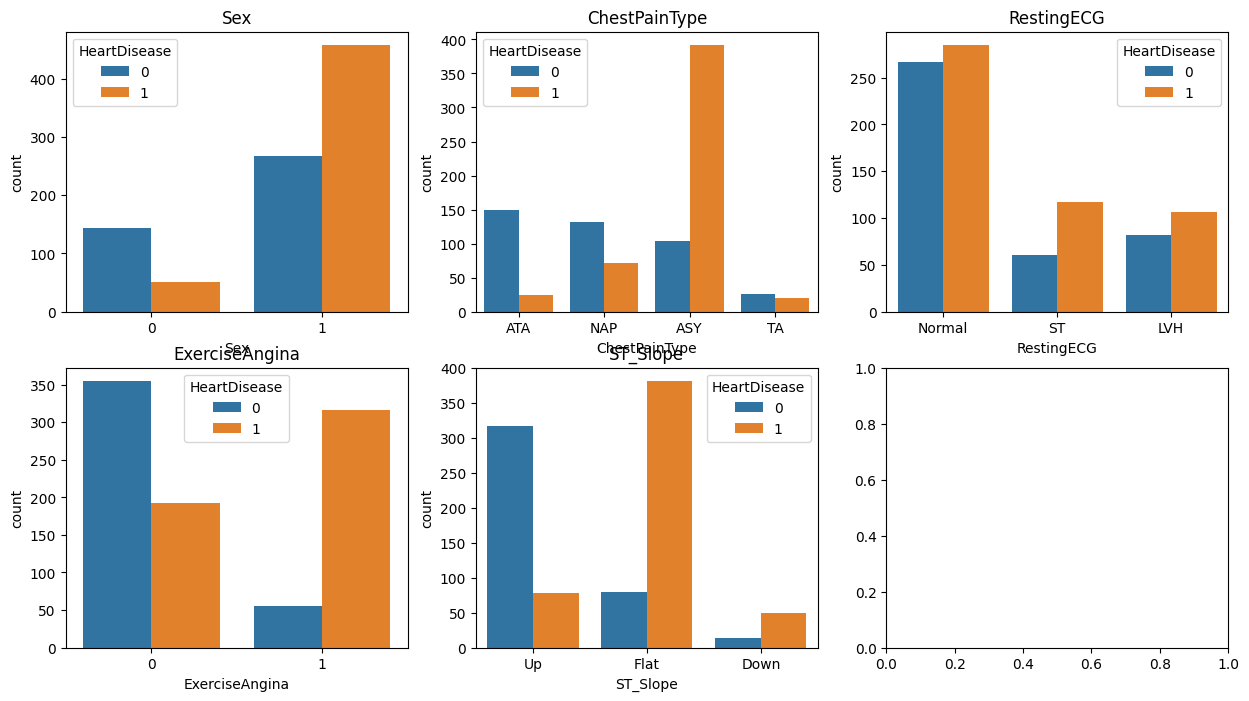

In [106]:
n_cols = len(cat_cols.columns)
n_rows = int(np.ceil(n_cols / 3))

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(cat_cols.columns):
    sns.countplot(data=heart, x=col, hue=target, ax=axes[idx])
    axes[idx].set_title(f'{col}')

['Sex', 'ExerciseAngina', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']


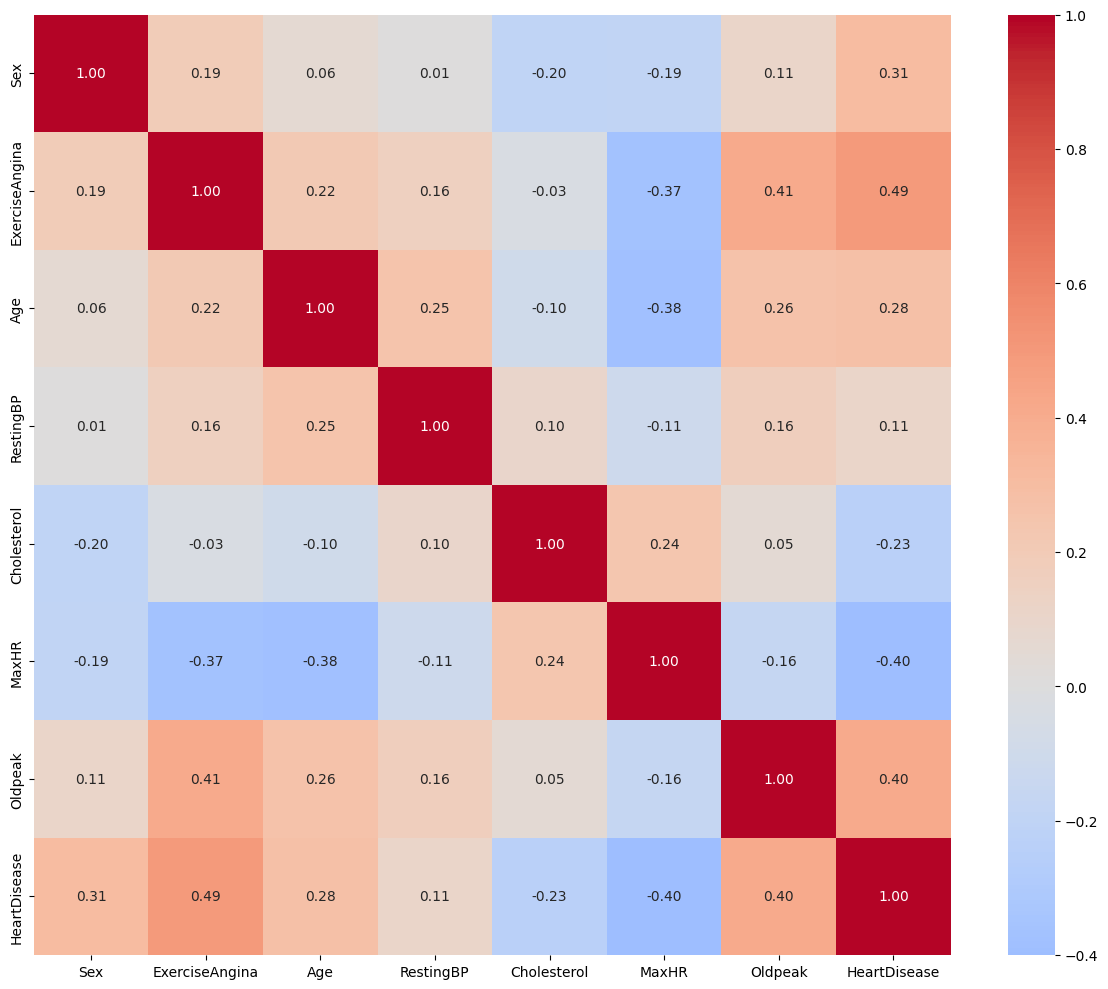

In [ ]:
# Included Sex and ExerciseAngina as they are encoded numerically.
plot_cols = ['Sex', 'ExerciseAngina'] + num_cols.columns.tolist()
print(plot_cols)

plt.figure(figsize=(12, 10))
corr = heart[plot_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

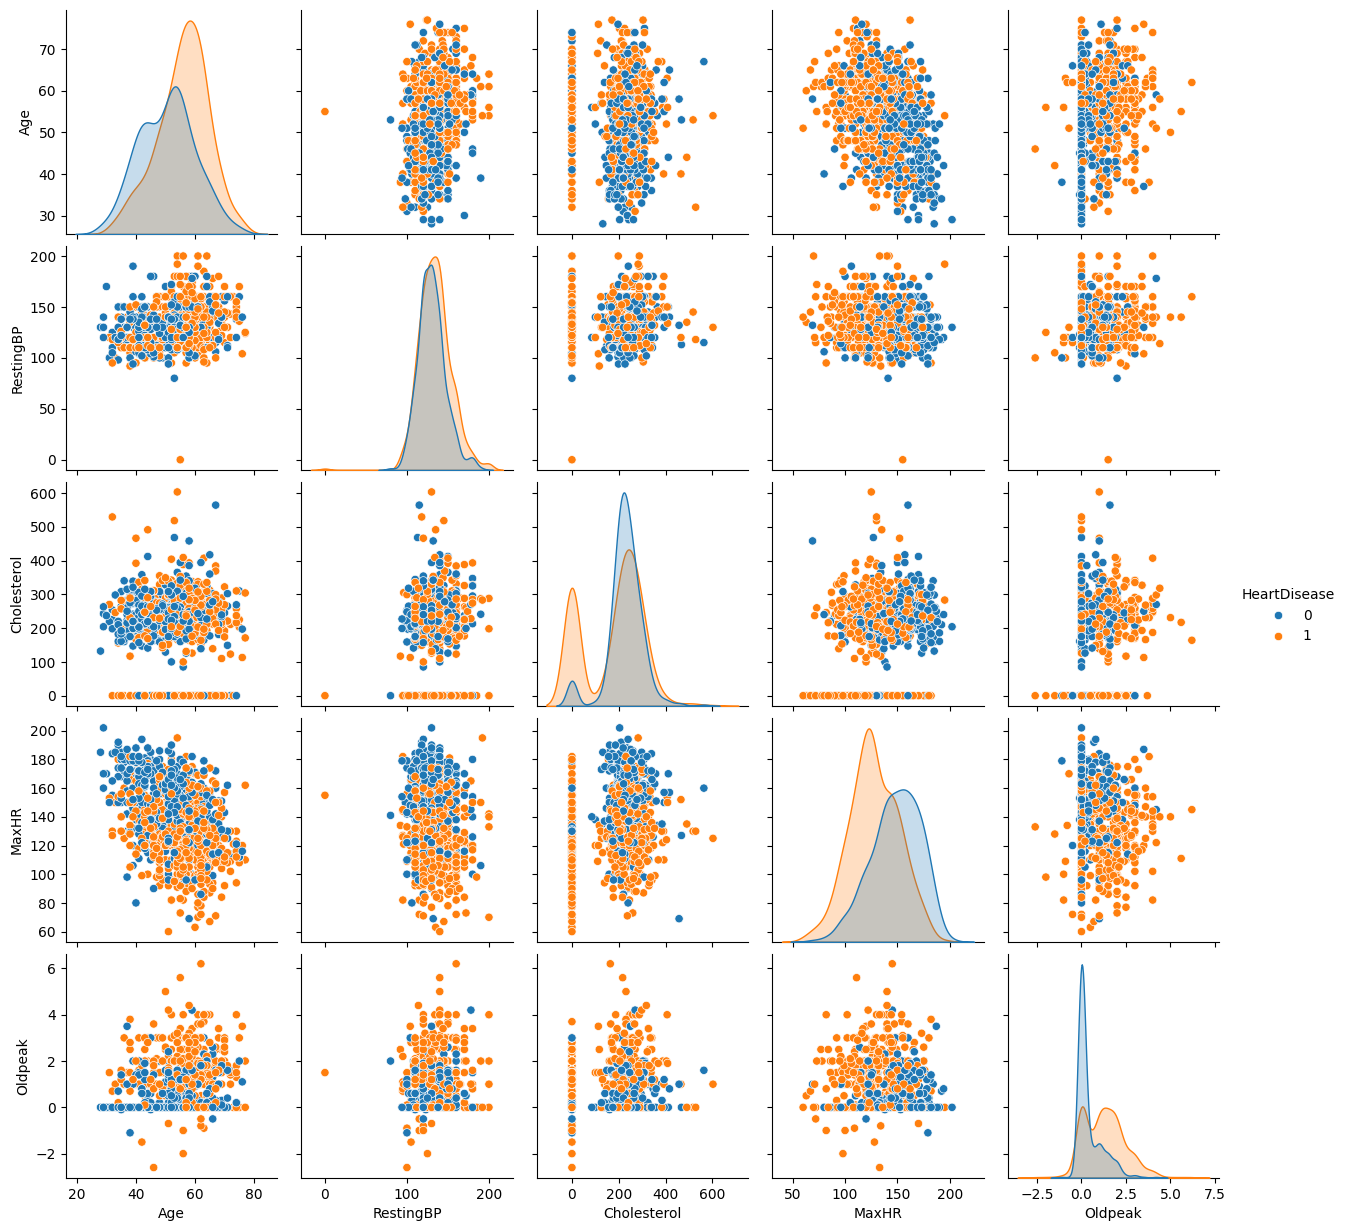

In [108]:
sns.pairplot(data=heart[num_cols.columns.tolist()], hue=target)
plt.show()

In [109]:
from sklearn.model_selection import train_test_split

X = heart.drop(columns=[target])
y = heart[target]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

In [110]:
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=cat_cols.columns)
X_train = encoder.fit_transform(X_train, y_train)
X_val = encoder.transform(X_val)
X_test = encoder.transform(X_test)

# X_train = pd.get_dummies(X_train, columns=cat_cols.columns, drop_first=True).astype(int)
# X_val = pd.get_dummies(X_val, columns=cat_cols.columns, drop_first=True).astype(int)
# X_test = pd.get_dummies(X_test, columns=cat_cols.columns, drop_first=True).astype(int)

scale_cols = num_cols.drop(target, axis=1).columns.tolist()
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols] = scaler.transform(X_val[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, recall_score, 
    precision_score, f1_score, confusion_matrix, 
    roc_curve, roc_auc_score, auc
)
import pandas as pd
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'k-NN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=42, probability=True),
    'Kernel SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=4),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss')
}

fit_models = {}

val_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    fit_models[name] = model
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    val_results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
        'Accuracy': accuracy_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Specificity': specificity,
        'F1 Score': f1_score(y_val, y_pred)
    })

val_results_df = pd.DataFrame(val_results)
print(val_results_df.to_string(index=False))

              Model  ROC-AUC  Accuracy   Recall  Precision  Specificity  F1 Score
Logistic Regression 0.915323  0.862319 0.868421   0.880000     0.854839  0.874172
               k-NN 0.873090  0.833333 0.855263   0.844156     0.806452  0.849673
        Naive Bayes 0.909805  0.869565 0.881579   0.881579     0.854839  0.881579
                SVM 0.911927  0.862319 0.868421   0.880000     0.854839  0.874172
         Kernel SVM 0.911927  0.862319 0.868421   0.880000     0.854839  0.874172
      Decision Tree 0.900361  0.833333 0.868421   0.835443     0.790323  0.851613
      Random Forest 0.919673  0.818841 0.881579   0.807229     0.741935  0.842767
  Gradient Boosting 0.912458  0.840580 0.881579   0.837500     0.790323  0.858974
            XGBoost 0.901740  0.847826 0.868421   0.857143     0.822581  0.862745


In [112]:
# If our goal is to identify everyone with even a slight possibility of having a heart attack, 
# then its about how well we can distinguish Positive (heart attack) cases. If we can minimize
# False Negatives (no heart attack) then we can get closer to our goal. 

# Looking at the validation results, RF achievest the highest ROC-AUC, meaning that it is superior 
# when it comes to distinguishing classes. However, are we really investigating 0-1 results
# or do we want to measure how well our model performs for positive cases specifically?
# By definition and considering our goal, Recall will be our metric to use.

# NB, RF, and Gradient boosting achieves 0.881579 recall and outperforms other models in validation for identifying positive cases. 
# Based on this result, choosing RF looks like the best option because amongst these top 3 recall models it has the highest ROC-AUC score.

In [113]:
test_results = []
for name, model in fit_models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    test_results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Specificity': specificity,
        'F1 Score': f1_score(y_test, y_pred)
    })

test_results_df = pd.DataFrame(test_results)
print(test_results_df.to_string(index=False))

              Model  ROC-AUC  Accuracy   Recall  Precision  Specificity  F1 Score
Logistic Regression 0.931876  0.876812 0.907895   0.873418     0.838710  0.890323
               k-NN 0.885930  0.833333 0.881579   0.827160     0.774194  0.853503
        Naive Bayes 0.945458  0.898551 0.894737   0.918919     0.903226  0.906667
                SVM 0.936757  0.905797 0.934211   0.898734     0.870968  0.916129
         Kernel SVM 0.936757  0.905797 0.934211   0.898734     0.870968  0.916129
      Decision Tree 0.917233  0.847826 0.868421   0.857143     0.822581  0.862745
      Random Forest 0.928268  0.913043 0.934211   0.910256     0.887097  0.922078
  Gradient Boosting 0.936757  0.898551 0.907895   0.907895     0.887097  0.907895
            XGBoost 0.923599  0.876812 0.881579   0.893333     0.870968  0.887417


In [127]:
# Evaluating test set results, RF, our selected model, again achieves the highest Recall (0.934211) along with SVM and Kernel SVM. 
# Since test results are our final measurements, we can conclude that our final model is RF for this goal as there's no better recall scores.

rf_test_recall = test_results_df.loc[test_results_df['Model'] == 'Random Forest', 'Recall'].values[0]
print(f"My best model (Random Forest) achieves a Recall of {rf_test_recall:.4f} on the Test set.")

My best model (Random Forest) achieves a Recall of 0.9342 on the Test set.


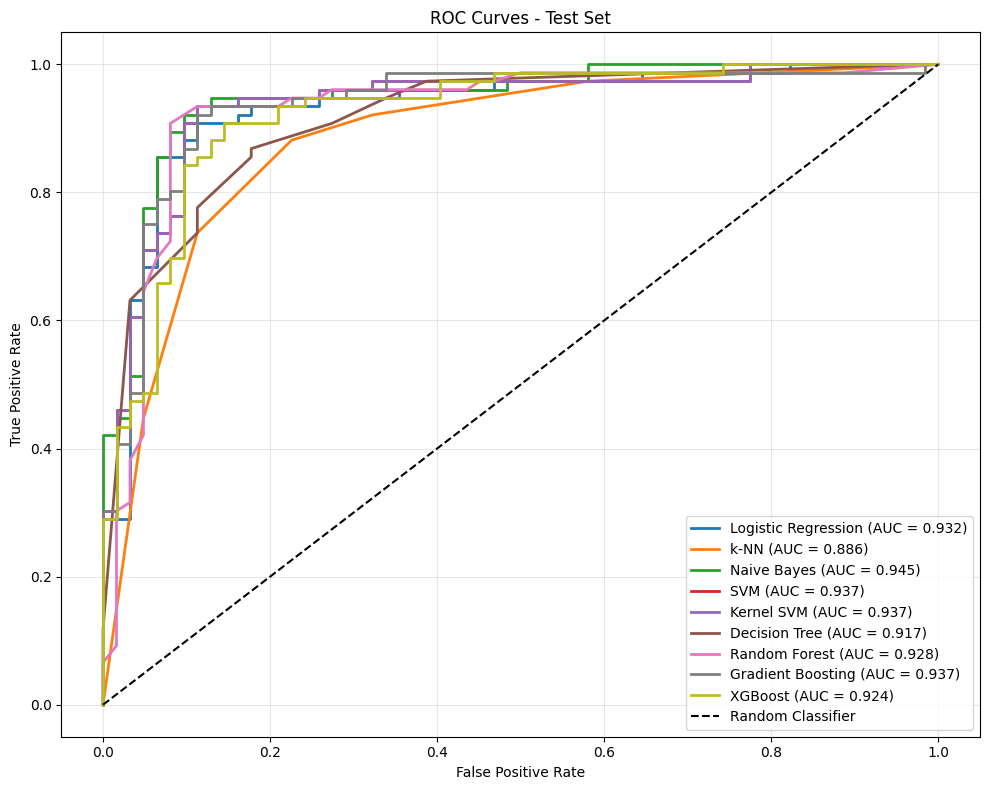

In [115]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [116]:
# Although majority of the models show a strong >0.90 similar ROC-AUC score (discriminative ability), NB achieves 0.945 ROC-AUC score 
# so it is the dominant model in this plot.
# Our RF achieves 0.928 ROC-AUC is an acceptable little trade-off for having better recall.

## Problem 2: Decision Tree (40 pts)

1) Take the decision tree (single tree) model you trained in the previous problem and plot the tree itself.
2) Create the feature importance plot.
3) Take the most important two numerical features (not categorical!), retrain the decision tree (single tree) with those two features, then make a 2D decision boundary plot similar to the one below. (Note: the plot below is just an example, yours may be different. Also, the boundaries may not be good for those features. That's okay; the aim here is visualization.)

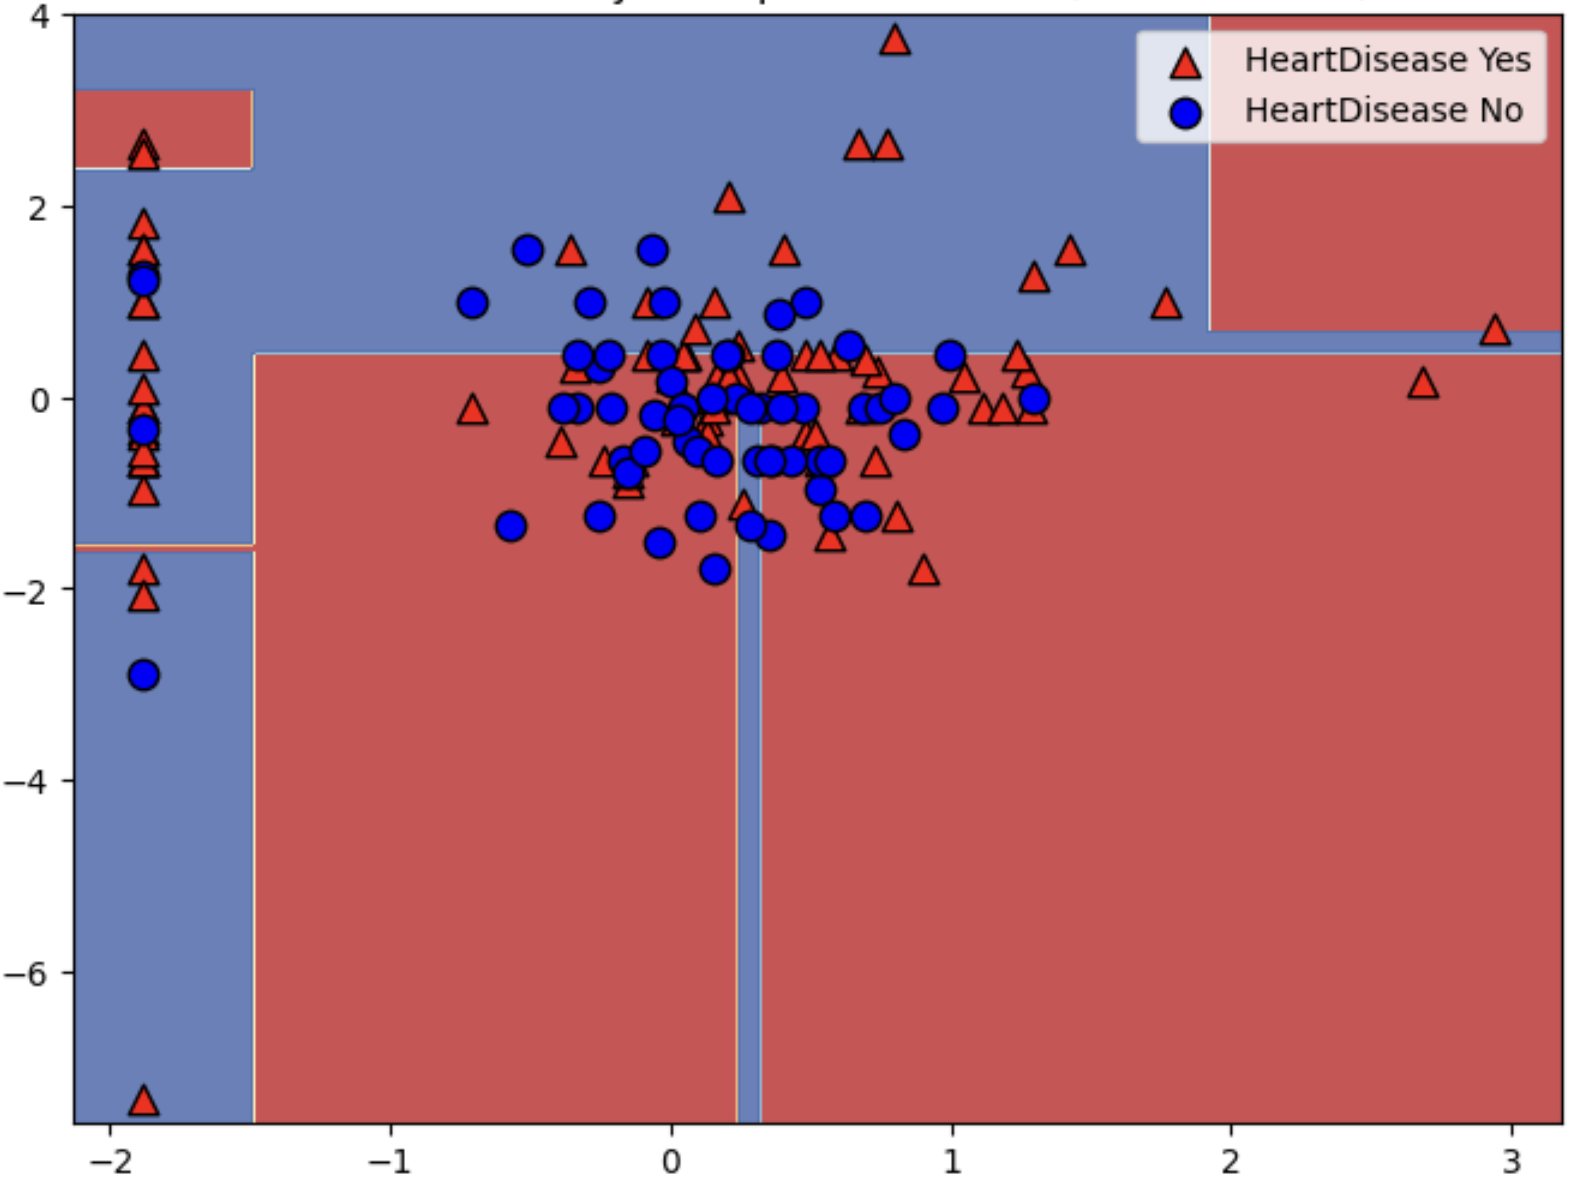

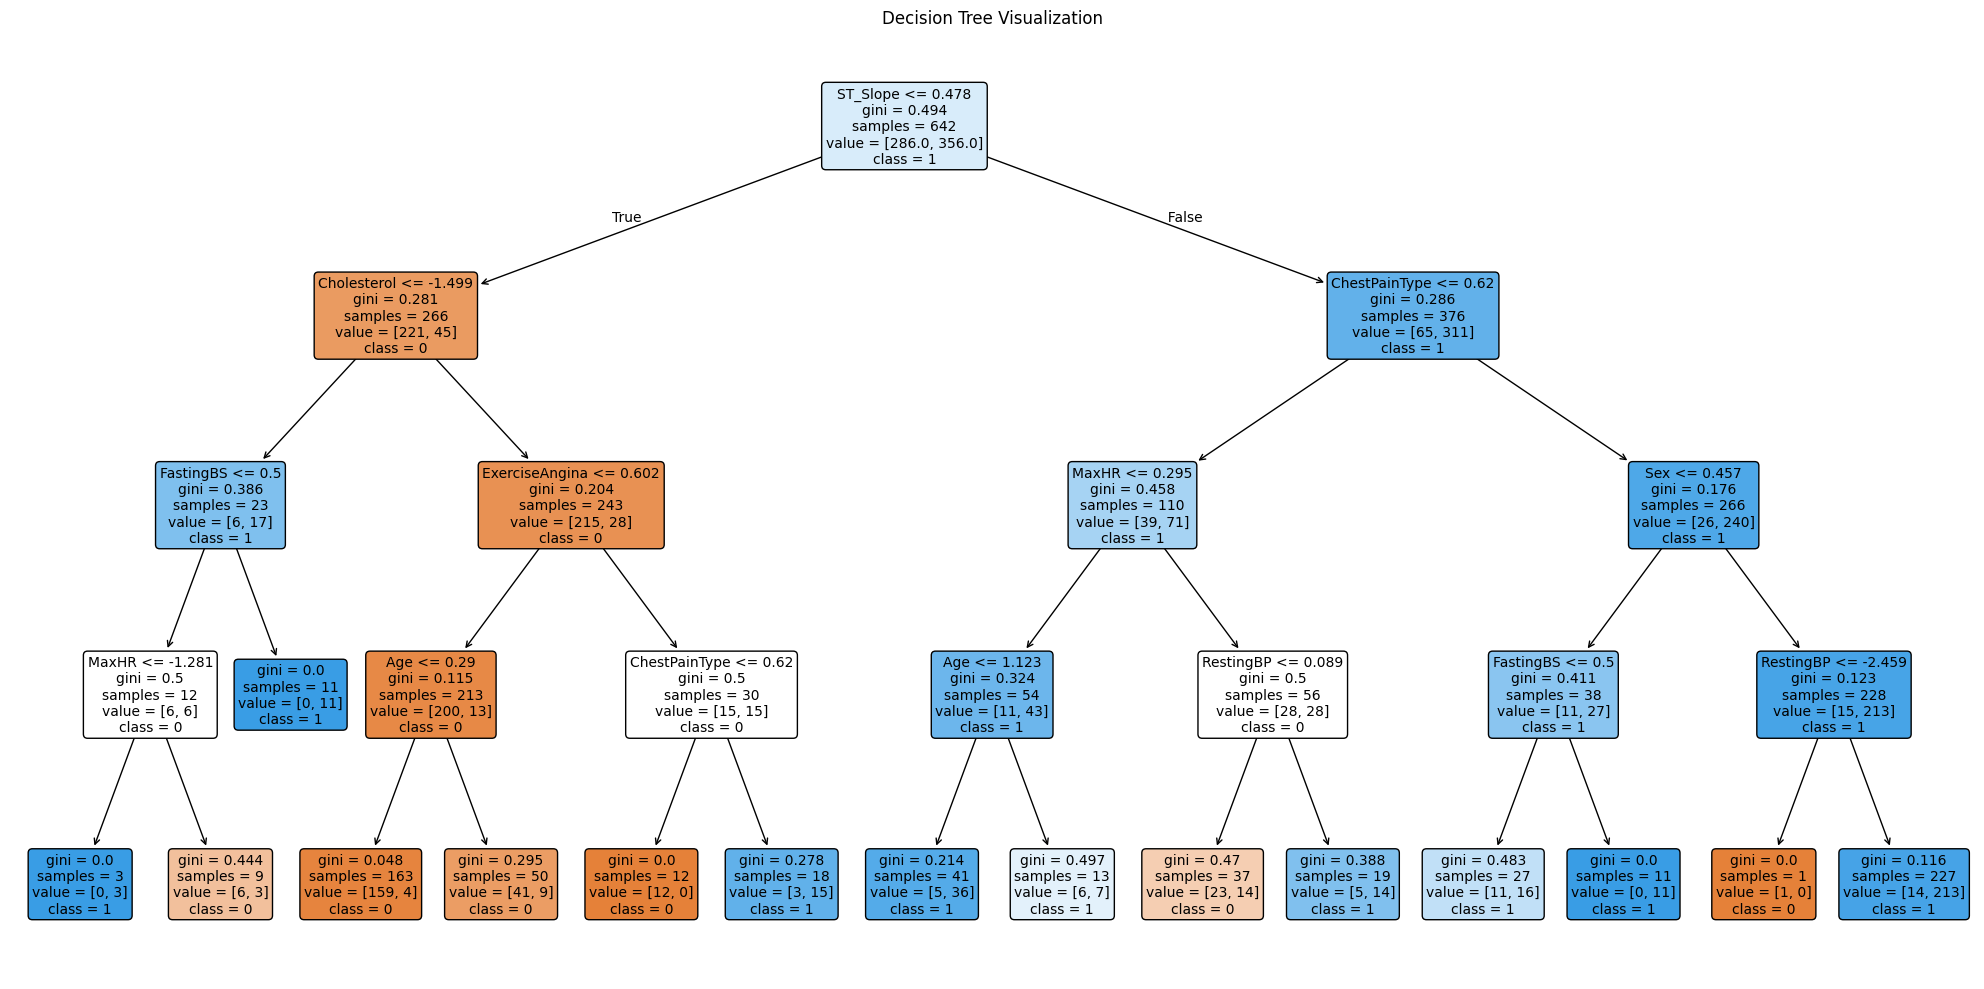

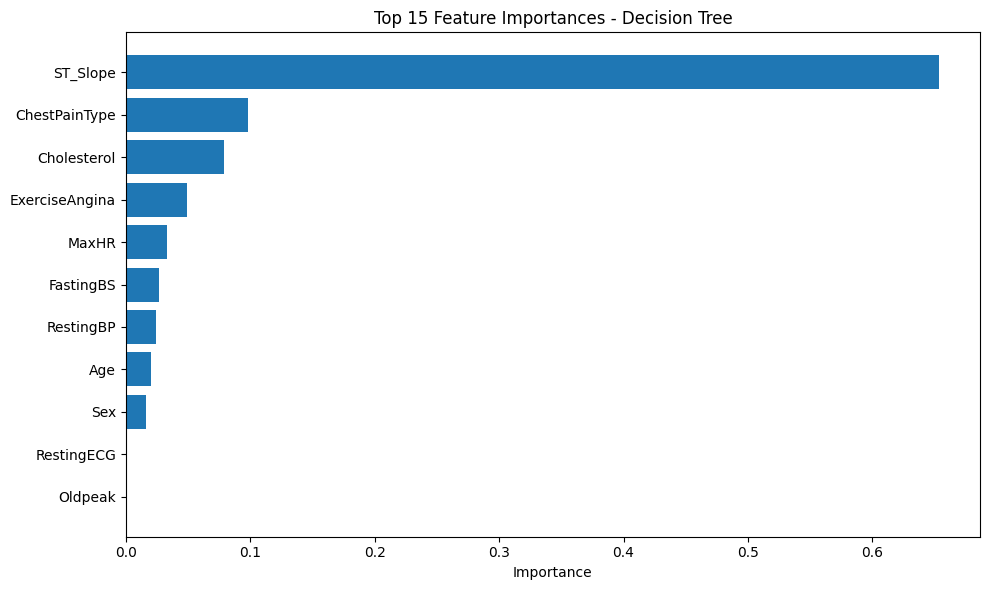

           feature  importance
10        ST_Slope    0.653837
2    ChestPainType    0.098228
4      Cholesterol    0.079292
8   ExerciseAngina    0.049125
7            MaxHR    0.033093
5        FastingBS    0.026487
3        RestingBP    0.024137
0              Age    0.020000
1              Sex    0.015800
6       RestingECG    0.000000
9          Oldpeak    0.000000


In [117]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 10))
plot_tree(fit_models['Decision Tree'], 
          feature_names=X_train.columns,
          class_names=['0', '1'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

importances = fit_models['Decision Tree'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'][:15], feature_importance_df['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance_df)

In [ ]:
new_dt = DecisionTreeClassifier(random_state=42, max_depth=10)

# ST_Slope and ChestPainType are actually my most important features but essentially they are categorical, since it is requested to skip categoricals,
# I take the most informative base numeric columns.

feature_a = "Cholesterol"
feature_b = "MaxHR"

top_2_cols = [feature_a, feature_b]

new_dt.fit(X_train[top_2_cols], y_train)
y_pred_dt = new_dt.predict(X_val[top_2_cols])
y_pred_proba_dt = new_dt.predict_proba(X_val[top_2_cols])[:, 1]

tn, fp, fn, tp = confusion_matrix(y_val, y_pred_dt).ravel()
specificity = tn / (tn + fp)

# VAL
dt_results = {
    'Model': name,
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba_dt),
    'Accuracy': accuracy_score(y_val, y_pred_dt),
    'Recall': recall_score(y_val, y_pred_dt),
    'Precision': precision_score(y_val, y_pred_dt),
    'Specificity': specificity,
    'F1 Score': f1_score(y_val, y_pred_dt)
}

print(dt_results)

{'Model': 'XGBoost', 'ROC-AUC': 0.672962648556876, 'Accuracy': 0.6521739130434783, 'Recall': 0.6447368421052632, 'Precision': 0.7, 'Specificity': np.float64(0.6612903225806451), 'F1 Score': 0.6712328767123288}


In [125]:
y_pred_dt = new_dt.predict(X_test[top_2_cols])
y_pred_proba_dt = new_dt.predict_proba(X_test[top_2_cols])[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()
specificity = tn / (tn + fp)

# TEST
dt_results_test = {
    'Model': name,
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_dt),
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Specificity': specificity,
    'F1 Score': f1_score(y_test, y_pred_dt)
}

print(dt_results_test)

{'Model': 'XGBoost', 'ROC-AUC': 0.6272283531409168, 'Accuracy': 0.6231884057971014, 'Recall': 0.6578947368421053, 'Precision': 0.6578947368421053, 'Specificity': np.float64(0.5806451612903226), 'F1 Score': 0.6578947368421053}


/Users/yigitates/Desktop/notebooks/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


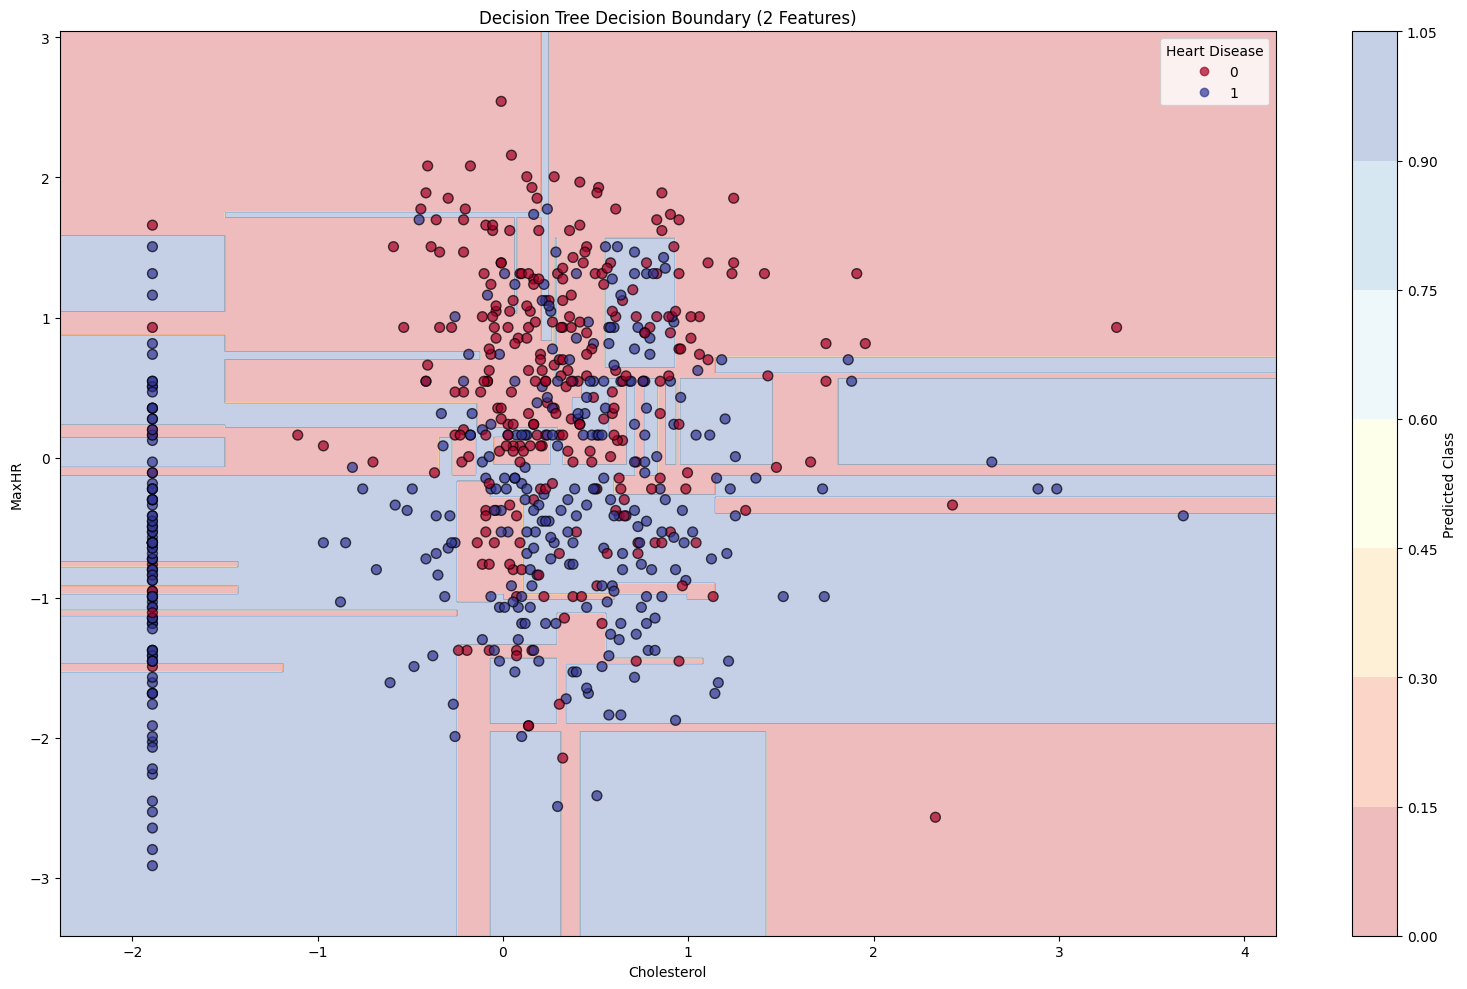

In [123]:
import numpy as np
import matplotlib.pyplot as plt


x_min, x_max = X_train[feature_a].min() - 0.5, X_train[feature_a].max() + 0.5
y_min, y_max = X_train[feature_b].min() - 0.5, X_train[feature_b].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))

Z = new_dt.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(16, 10))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.colorbar(label='Predicted Class')

scatter = plt.scatter(X_train[feature_a], X_train[feature_b], 
                     c=y_train, cmap='RdYlBu', edgecolors='black', s=50, alpha=0.7)
plt.xlabel(f'{feature_a}')
plt.ylabel(f'{feature_b}')
plt.title('Decision Tree Decision Boundary (2 Features)')
plt.legend(*scatter.legend_elements(), title="Heart Disease")
plt.tight_layout()
plt.show()